# N2 · 图的诚实性: 截断 y 轴怎么骗人 (Figure Honesty)

> 配套 9.6-L4 · **真实科研动作**: 用同一份数据画「截断 y 轴 (骗人) vs 诚实」两张图,
> 亲眼看一个微小差距怎么被视觉放大成「巨大提升」, 守住 9.3 攻击清单的可视化底线。

In [1]:
import sys
from pathlib import Path
SRC = Path.cwd().parent / "src"
EXP_SRC = Path.cwd().parent.parent / "experiment-design" / "src"   # 复用 9.4 实验数据
for p in (SRC, EXP_SRC):
    sys.path.insert(0, str(p))
import numpy as np
import matplotlib.pyplot as plt
import experiment as ex
import plotstyle as ps
ps.set_pub_style()

# 取一个**本质很小**的差距: noise=0 下 DPO vs Robust-DPO (9.4 证明过此处不显著)
nz = 0.0
dpo = np.mean(ex.runs_for(ex.ablation_grid(seeds=range(8)), method="DPO", noise=nz))
rob = np.mean(ex.runs_for(ex.ablation_grid(seeds=range(8)), method="Robust-DPO", noise=nz))
print(f"noise=0 下: DPO={dpo:.3f}, Robust-DPO={rob:.3f}, 差距仅 {rob-dpo:+.3f} (9.4 证明不显著)")

noise=0 下: DPO=0.619, Robust-DPO=0.615, 差距仅 -0.004 (9.4 证明不显著)


## 1. 同一份数据, 两种画法

左: 截断 y 轴 (从 0.60 开始) —— 把 ~0.01 的差距视觉放大成"碾压"。
右: 诚实 (y 从 0) —— 还原差距的真实 (微小) 大小。

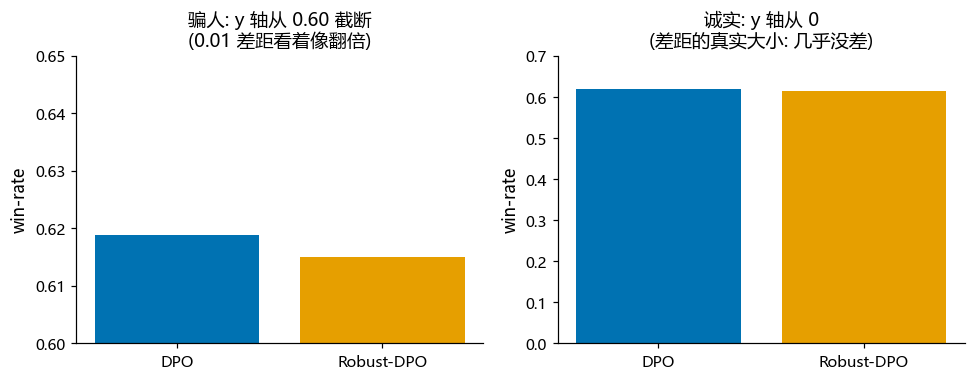

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.6))
vals = [dpo, rob]; labels = ["DPO", "Robust-DPO"]
colors = ps.OKABE_ITO[:2]

# 左: 骗人 (y 轴截断)
ax1.bar(labels, vals, color=colors)
ax1.set_ylim(0.60, 0.65)          # ← 截断! 罪魁
ax1.set_ylabel("win-rate"); ax1.set_title("骗人: y 轴从 0.60 截断\n(0.01 差距看着像翻倍)")

# 右: 诚实 (y 从 0)
ax2.bar(labels, vals, color=colors)
ax2.set_ylim(0, 0.7)              # ← 诚实
ax2.set_ylabel("win-rate"); ax2.set_title("诚实: y 轴从 0\n(差距的真实大小: 几乎没差)")
plt.tight_layout(); plt.show()

## 2. 量化「被吹大了多少倍」

视觉上柱子高度的**比例**才是读者一瞥时感知的。算算截断把感知差距放大了几倍。

In [3]:
true_gap = rob - dpo
# 诚实图 (y:0~0.7): 柱高比例差
honest_ratio = (rob - dpo) / 0.7
# 截断图 (y:0.60~0.65): 柱高比例差
trunc_ratio  = (rob - dpo) / (0.65 - 0.60)
print(f"真实差距: {true_gap:+.3f} win-rate")
print(f"诚实图里, 柱高差占轴长: {honest_ratio*100:.1f}%  (看着也就这么点)")
print(f"截断图里, 柱高差占轴长: {trunc_ratio*100:.0f}%  ← 视觉放大 {trunc_ratio/honest_ratio:.0f} 倍!")
print("\n→ 同一个数, 一个轴范围就能把'没差'画成'碾压'。这是 9.3 攻击清单的可视化版。")
print("→ 规则: 柱状图 y 轴几乎总从 0; 视觉冲击必须匹配效应真实大小 (L4)。")

真实差距: -0.004 win-rate
诚实图里, 柱高差占轴长: -0.5%  (看着也就这么点)
截断图里, 柱高差占轴长: -8%  ← 视觉放大 14 倍!

→ 同一个数, 一个轴范围就能把'没差'画成'碾压'。这是 9.3 攻击清单的可视化版。
→ 规则: 柱状图 y 轴几乎总从 0; 视觉冲击必须匹配效应真实大小 (L4)。


## 3. 给诚实版配一条 self-contained 图注 (L4)

图注要让图脱离正文也能读懂 (审稿人常只看图+图注)。

In [4]:
caption = """图 X: 在无噪声偏好数据上, Robust-DPO 与 DPO 的 win-rate 几乎无差异。
柱为 8 个随机种子均值, 误差棒省略 (差距 <0.02, 不显著, p≈0.14)。
y 轴从 0 起以如实反映效应大小。此图佐证: Robust-DPO 的机制仅在高噪声下起作用
(见图 3 的交互效应), 而非全场景提升。"""
print(caption)
print("\n注意图注首句是**结论**(几乎无差异), 而非'DPO vs Robust-DPO 对比' 式描述。")

图 X: 在无噪声偏好数据上, Robust-DPO 与 DPO 的 win-rate 几乎无差异。
柱为 8 个随机种子均值, 误差棒省略 (差距 <0.02, 不显著, p≈0.14)。
y 轴从 0 起以如实反映效应大小。此图佐证: Robust-DPO 的机制仅在高噪声下起作用
(见图 3 的交互效应), 而非全场景提升。

注意图注首句是**结论**(几乎无差异), 而非'DPO vs Robust-DPO 对比' 式描述。


## 4. 反思 (9.6 收口)

你刚亲手制造并拆穿了「截断 y 轴」这个头号可视化骗术。带走:
- **柱状图 y 轴几乎总从 0**; 折线为看趋势可不从 0, 但要标清且不夸大微小差距。
- **视觉冲击 = 效应真实大小**。不显著的差距 (9.4-L5) 不该画得很震撼。
- 用 9.3 攻击清单**自查每张图**: 你希望别人怎么诚实待你, 就怎么待读者。
- 图注 self-contained, 首句是结论。

> **9.6 全线回顾**: L1 判断力 → L2 出版级 → L3 方法图 → L4 诚实。同一份 9.4 数据走完出图全程。

> 交棒 9.7: 图准备好了, 现在把整个研究**写成论文**投出去 ——
> 下一专题 `paper-writing-submission` 升级你已有的 how_to_write_a_paper, 补投稿/rebuttal 下半场。